In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('/content/credit_card_fraud_dataset.csv')

In [3]:
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [4]:
df.tail()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
99995,99996,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,0
99996,99997,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,0
99997,99998,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,0
99998,99999,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,0
99999,100000,2024-03-05 19:41:36.027606,1596.79,675,refund,Houston,0


In [5]:
df.shape

(100000, 7)

In [7]:
df.columns

Index(['TransactionID', 'TransactionDate', 'Amount', 'MerchantID',
       'TransactionType', 'Location', 'IsFraud'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB


In [9]:
df['IsFraud'].value_counts()

,count
IsFraud,
0,99000
1,1000


In [11]:
# Missing Values
df.isnull().sum()

,0
TransactionID,0
TransactionDate,0
Amount,0
MerchantID,0
TransactionType,0
Location,0
IsFraud,0


In [12]:
df.drop(columns=['TransactionID'], inplace=True)

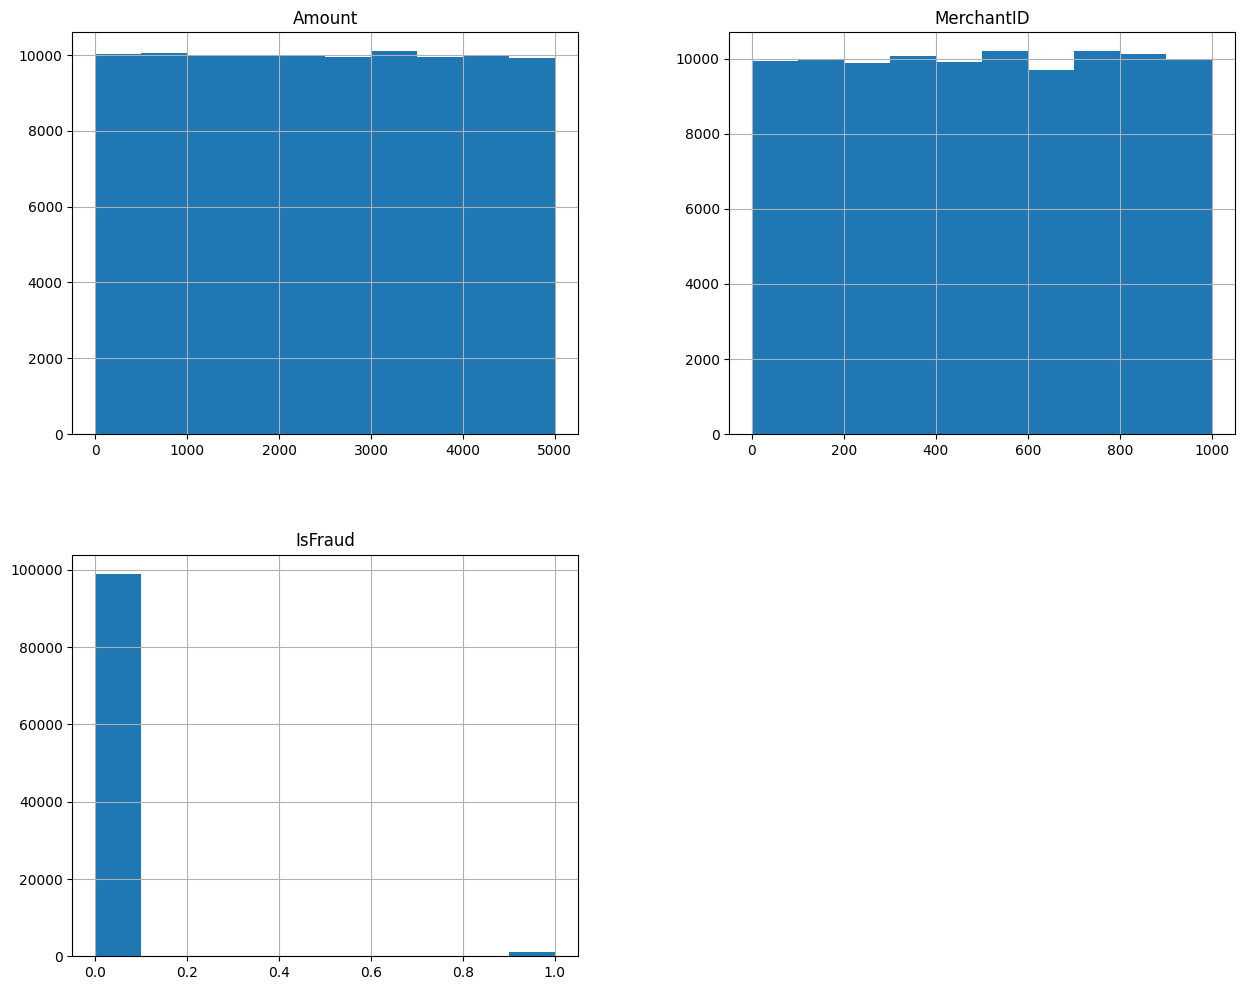

In [13]:
# Univariate Analysis
df.hist(figsize = (15,12))
plt.show()

In [18]:
# Separating Numerical and Categorical columns.
num_col = df.select_dtypes(include=['int64', 'float64']).columns
cat_col = df.select_dtypes(include=['object']).columns

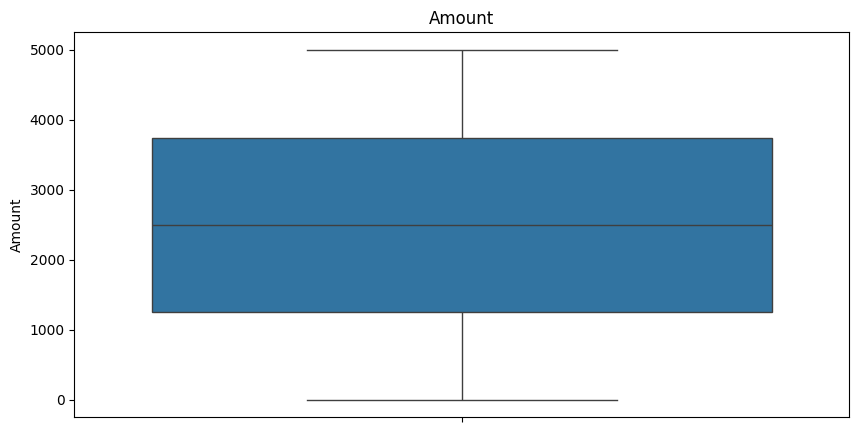

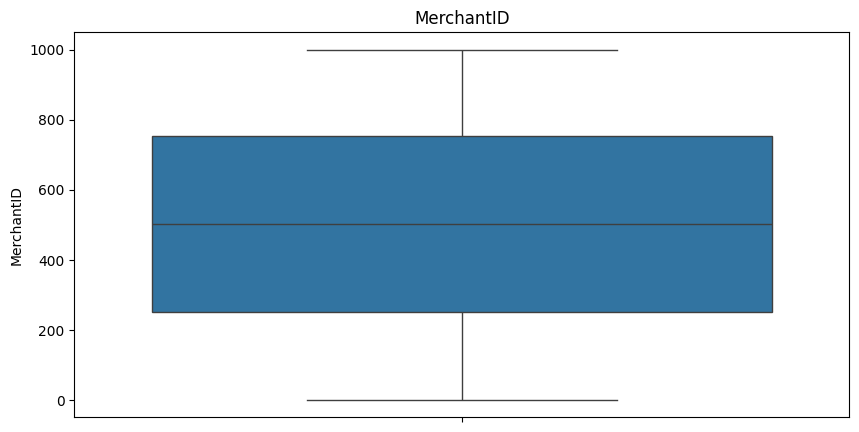

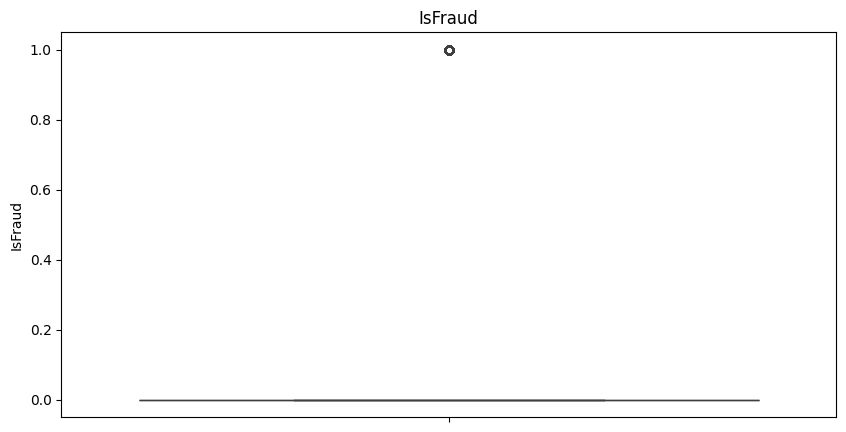

In [19]:
# Box Plot
for col in num_col:
  plt.figure(figsize=(10,5))
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

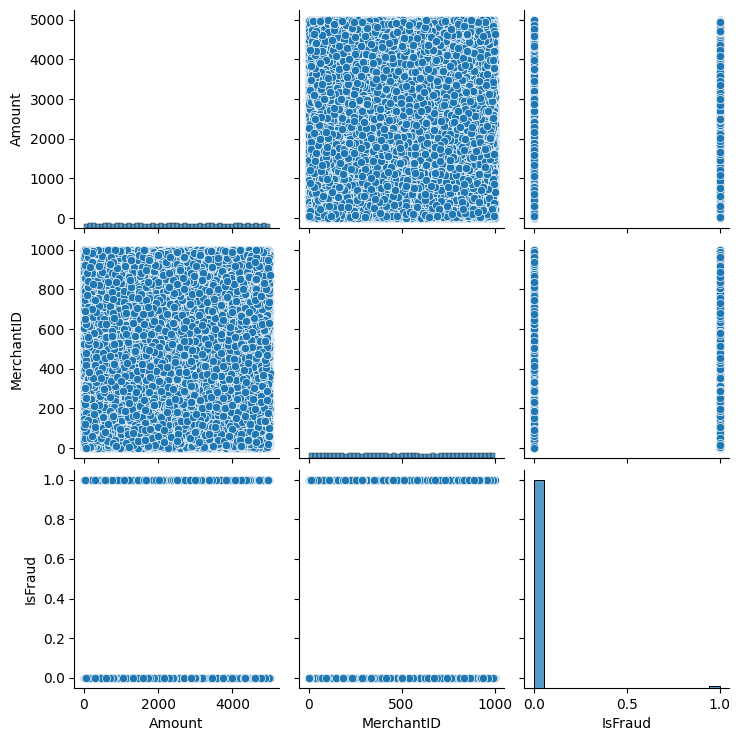

In [22]:
# Multivariate Data
sns.pairplot(df)
plt.show()

In [24]:
# Lable Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_col:
  df[col] = le.fit_transform(df[col].astype(str))
df.head()

,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,38961,4189.27,688,1,7,0
1,34235,2659.71,109,1,1,0
2,12900,784.00,394,0,4,0
3,42117,3514.40,944,0,5,0
4,69408,369.07,475,0,6,0


In [25]:
df = df.astype(int)
df

,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,38961,4189,688,1,7,0
1,34235,2659,109,1,1,0
2,12900,784,394,0,4,0
3,42117,3514,944,0,5,0
4,69408,369,475,0,6,0
...,...,...,...,...,...,...
99995,58601,1057,289,1,7,0
99996,36224,297,745,1,7,0
99997,56740,3448,690,0,7,0
99998,99118,3750,644,0,5,0


In [26]:
# Target variable
X = df.drop('IsFraud', axis=1)
y = df['IsFraud']

print(X.head())
print(y.head())

   TransactionDate  Amount  MerchantID  TransactionType  Location
0            38961    4189         688                1         7
1            34235    2659         109                1         1
2            12900     784         394                0         4
3            42117    3514         944                0         5
4            69408     369         475                0         6
0    0
1    0
2    0
3    0
4    0
Name: IsFraud, dtype: int64


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Gradient Boosting Classifier = because models are trained sequentially.
model = GradientBoostingClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9883


In [29]:
# Random Forest Classifier
model1 = RandomForestClassifier()
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.98935


In [30]:
# Hyper Parameter Tuning
model2 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,subsample = 0.8,random_state=42)
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9864


In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9864
[[19728    59]
 [  213     0]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19787
           1       0.00      0.00      0.00       213

    accuracy                           0.99     20000
   macro avg       0.49      0.50      0.50     20000
weighted avg       0.98      0.99      0.98     20000



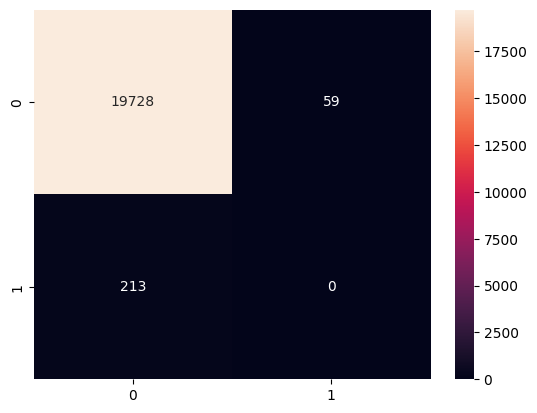

In [32]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [33]:
# Checking Overfitting
print("Train Accuracy:", accuracy_score(y_train, model.predict(X_train)))
print("Test Accuracy: ", accuracy_score(y_test,  model.predict(X_test)))

Train Accuracy: 0.9915125
Test Accuracy:  0.9883
